In [1]:
import os
import json
from shapely.geometry import Polygon
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from PIL import Image, ImageDraw, ImageFont
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")

In [15]:
output_folder = os.path.join(PROJECT_ROOT, "data", "processed", "segmented_images")
files_folder = os.listdir(output_folder)

Calculate the area per bound

In [4]:
area_txt_lines = []
for img_segm in files_folder:
    json_path = os.path.join(output_folder, img_segm)
    with open(json_path, "r", encoding="utf-8") as f:
        kraken_output = json.load(f)
    txt_lines = kraken_output.get("lines", [])
    area_txt_lines.append([Polygon(bounds.get("boundary", [])).area for bounds in txt_lines])

Distribution of number of text lines per image

In [5]:
num_txt_lines = [len(lines) for lines in area_txt_lines]
stats = pd.Series(num_txt_lines).describe(percentiles=[0.1, 0.25, 0.75, 0.90])
stats

count     71.000000
mean     197.338028
std       18.303742
min      101.000000
10%      193.000000
25%      197.000000
50%      201.000000
75%      204.000000
90%      210.000000
max      219.000000
dtype: float64

In [6]:
ind_min_txt_lines = num_txt_lines.index(stats["min"])
print(f"Index of minimum text line count: {ind_min_txt_lines}")
print(f"Corresponding file: {files_folder[ind_min_txt_lines]}")
ind_max_txt_lines = num_txt_lines.index(stats["max"])
print(f"Index of maximum text line count: {ind_max_txt_lines}")
print(f"Corresponding file: {files_folder[ind_max_txt_lines]}")

Index of minimum text line count: 70
Corresponding file: 75_f_070v_garde.json
Index of maximum text line count: 69
Corresponding file: 74_f_069v_070.json


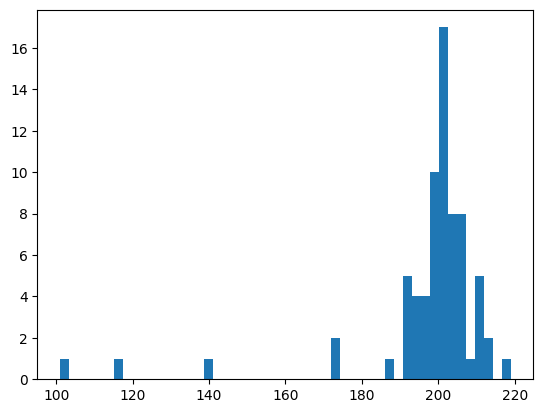

In [ ]:
plt.hist(num_txt_lines,bins=50)
plt.show()

Bound's area distribution overall images

In [7]:
full_area_txt_lines = list(itertools.chain.from_iterable(area_txt_lines))
print(f"Total number of text lines: {len(full_area_txt_lines)}")

Total number of text lines: 14011


In [71]:
stats = pd.Series(full_area_txt_lines).describe(percentiles=[0.01,0.02,0.021,0.022,0.023,0.024,0.025,0.026,0.027,0.028,0.029,0.03,0.031,0.032,0.033,0.04,0.05,0.1, 0.25, 0.75, 0.99,0.995,0.999])
stats

count    14011.000000
mean     12230.803440
std       2562.398822
min        100.500000
1%         750.450000
2%        1526.300000
2.1%      1668.710000
2.2%      1731.710000
2.3%      1879.495000
2.4%      2058.780000
2.5%      2231.375000
2.6%      2466.980000
2.7%      2722.370000
2.8%      3081.280000
2.9%      3502.385000
3%        4058.750000
3.1%      4461.095000
3.2%      4809.120000
3.3%      5480.420000
4%        8416.000000
5%        9557.500000
10%      10788.000000
25%      11684.500000
50%      12474.500000
75%      13253.000000
99%      17092.500000
99.5%    18775.900000
99.9%    29904.155000
max      36947.000000
dtype: float64

In [72]:
large_bounds = [
    (i, j,area_txt_lines[i][j])
    for i, sublist in enumerate(area_txt_lines)
    for j, value in enumerate(sublist)
    if value >= stats["99.5%"]
]

print(len(large_bounds))

71


In [75]:
small_bounds_2 = [
    (i, j,area_txt_lines[i][j])
    for i, sublist in enumerate(area_txt_lines)
    for j, value in enumerate(sublist)
    if value <= stats["2%"]
]

print(len(small_bounds_2))
sorted_desc_small_bounds = sorted(small_bounds_2, key=lambda x: x[-1], reverse=True)
sorted_desc_small_bounds[:20]

281


[(35, 205, 1526.0),
 (45, 172, 1518.0),
 (39, 85, 1513.5),
 (21, 134, 1513.0),
 (44, 201, 1507.0),
 (36, 83, 1497.0),
 (55, 200, 1489.0),
 (0, 20, 1486.0),
 (45, 72, 1484.0),
 (66, 204, 1484.0),
 (0, 109, 1482.5),
 (21, 85, 1479.5),
 (61, 1, 1474.0),
 (61, 202, 1465.5),
 (1, 3, 1443.5),
 (59, 198, 1433.5),
 (0, 0, 1426.5),
 (67, 199, 1413.0),
 (48, 202, 1406.5),
 (64, 1, 1396.5)]

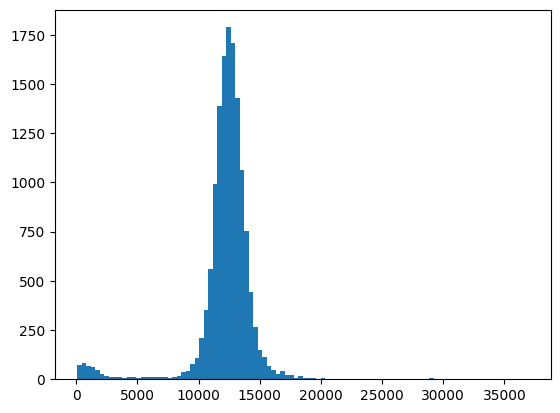

In [77]:
plt.hist(full_area_txt_lines,bins=100)
plt.show()

The segments with the 2% of lower area are excluded

In [81]:
bounds_to_filter = [
    (i, j)
    for i, sublist in enumerate(area_txt_lines)
    for j, value in enumerate(sublist)
    if value <= stats["2%"]
]

In [82]:
bounds_to_filter

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 7),
 (0, 20),
 (0, 54),
 (0, 67),
 (0, 109),
 (0, 110),
 (0, 111),
 (0, 112),
 (0, 113),
 (0, 114),
 (0, 115),
 (0, 116),
 (1, 0),
 (1, 1),
 (1, 3),
 (1, 55),
 (1, 106),
 (1, 136),
 (1, 208),
 (1, 209),
 (1, 210),
 (2, 98),
 (2, 99),
 (2, 125),
 (2, 161),
 (3, 0),
 (3, 111),
 (3, 112),
 (3, 200),
 (4, 0),
 (4, 20),
 (4, 89),
 (4, 100),
 (4, 102),
 (4, 197),
 (5, 19),
 (5, 51),
 (5, 96),
 (5, 191),
 (5, 192),
 (6, 20),
 (6, 22),
 (6, 66),
 (6, 89),
 (6, 96),
 (6, 97),
 (6, 99),
 (6, 201),
 (7, 50),
 (7, 73),
 (7, 150),
 (7, 151),
 (8, 0),
 (8, 64),
 (8, 102),
 (8, 202),
 (9, 50),
 (9, 51),
 (9, 102),
 (9, 195),
 (10, 27),
 (10, 97),
 (10, 183),
 (11, 0),
 (11, 2),
 (11, 6),
 (11, 7),
 (11, 105),
 (11, 106),
 (11, 160),
 (11, 211),
 (12, 33),
 (12, 101),
 (12, 145),
 (12, 205),
 (14, 0),
 (14, 1),
 (14, 30),
 (14, 193),
 (15, 0),
 (15, 103),
 (15, 104),
 (15, 204),
 (16, 51),
 (16, 94),
 (16, 142),
 (16, 198),
 (17, 0),
 (17, 1),
 (17, 100),
 (17,

In [83]:
filtered_area_txt_lines = [
    [value for j, value in enumerate(sublist) if (i, j) not in bounds_to_filter]
    for i, sublist in enumerate(area_txt_lines)
]

In [85]:
filtered_area_txt_lines

[[1605.0,
  11018.0,
  5692.0,
  4744.5,
  3847.5,
  6616.5,
  4104.0,
  4433.0,
  4529.5,
  4566.5,
  4478.0,
  4371.0,
  4220.5,
  11648.0,
  12503.5,
  13182.0,
  11900.0,
  13206.5,
  13611.5,
  12779.0,
  13230.0,
  12342.0,
  12530.5,
  12591.0,
  13213.0,
  11435.0,
  14370.5,
  11268.0,
  12817.5,
  12992.0,
  12140.0,
  11781.5,
  13277.5,
  12337.0,
  11619.5,
  11447.5,
  13430.5,
  11525.0,
  12142.0,
  12133.0,
  12418.5,
  14448.5,
  13108.5,
  12628.0,
  12420.0,
  12819.5,
  13956.0,
  14897.0,
  12591.0,
  12984.0,
  14431.0,
  14667.0,
  11648.5,
  12972.0,
  12894.0,
  12363.5,
  13046.0,
  12450.0,
  11479.5,
  13223.5,
  11420.0,
  14607.0,
  13617.0,
  12580.0,
  13542.0,
  10085.0,
  12285.0,
  13366.0,
  12297.5,
  14027.0,
  12595.0,
  12610.0,
  11546.0,
  13672.0,
  12068.5,
  13600.0,
  11526.5,
  13277.0,
  13899.5,
  13381.5,
  13698.5,
  11755.5,
  12917.5,
  12975.5,
  13309.0,
  14032.0,
  11076.5,
  11778.5,
  11902.0,
  11172.0,
  15015.5,
  25346.5,
